# Machine Learning 2 - HW 2

## Submission Instructions

This notebook contains all the questions. You should follow the instructions below.
Solutions for both theoretical and practical parts should be written in this notebook.

You should submit three files:
- IPYNB notebook:
  - All the wet and dry parts, including code, graphs, discussion, etc.
- Model weights:
  - Export the model's weights after training using a `.pt` or `.pkl` file (question 2).
- PDF file:
  - Export the notebook to PDF. Make sure that all the cells are visible.

All files should be in the following format: "HW2_ID1_ID2.file"

Good Luck!

# Question 1 - Generalization and Overfit (20 pt)

In this exercise, we will demonstrate overfitting to random labels. The settings are the following:

<li> Use the MNIST dataset.
<li> For model training - work on the first 128 samples from the train split.
<li> Fix the following parameters:
    <ul>
        <li> Shuffle to False.
        <li> Batch size to 128.
        <li> Use seed = 42 for reproducibility.
    </ul>

Generate random labels from Bernoulli distribution with a probability of $\frac{1}{2}$ (I.e., each sample is assigned a random label which is zero or one).

Show that by using a simple Fully Connected netwrok and cross-entropy loss, you are able to achieve a loss value of $\approx 0$ (the lower the better).

Plot the accuracy and loss convergence for this data and the test split of our dataset as a function of epochs.

Answer the following questions:

1. Describe the accuracy value of the test data as a function of epochs and explain the phenomenon.

2. Discuss the connection between model size (complexity) and the dataset size. How does it relate to generalization and overfitting?

3. Discuss general methods to avoid overfitting. Specially, discuss methods in three different levels: data, model, and training.

4. Find one academic paper that presents or analyzes a method for reducing overfitting in deep learning.

    The method may be: general or domain-specific, architecture-specific (e.g., CNNs, Transformers), or applied to a particular task (e.g., vision, NLP, biomedical data).

    Briefly summarize:

    - The overfitting problem addressed in the paper (if there is one)

    - The proposed method for reducing overfitting

    - The main findings or conclusions

    Include a link for the paper.

    For example, you might delve into the connection between model size (complexity) and the dataset size stated in https://arxiv.org/pdf/2001.08361
</p>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random
import matplotlib.pyplot as plt

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

batch_size = 128

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True)

train_data = trainset.data[:128].float().unsqueeze(1) / 255.0
train_labels = torch.tensor(np.random.binomial(1, 0.5, 128), dtype=torch.long)

test_data = test_set.data.float().unsqueeze(1) / 255.0
test_labels = torch.tensor(np.random.binomial(1, 0.5, len(test_set)), dtype=torch.long)

trainloader = torch.utils.data.DataLoader(list(zip(train_data, train_labels)), batch_size=batch_size, shuffle=False)
testloader  = torch.utils.data.DataLoader(list(zip(test_data,  test_labels )), batch_size=batch_size, shuffle=False)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 2)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=1e-3)


In [ ]:
def train_one_epoch(net, trainloader, criterion, optimizer):
    net.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in trainloader:
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        pred = outputs.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    avg_acc = 100.0 * correct / total
    return avg_loss, avg_acc


In [ ]:
@torch.no_grad()
def eval_one_epoch(net, testloader, criterion):
    net.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in testloader:
        outputs = net(inputs)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * labels.size(0)
        pred = outputs.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    avg_acc = 100.0 * correct / total
    return avg_loss, avg_acc


In [ ]:
def run_training(net, trainloader, testloader, criterion, optimizer, epochs=300, print_every=50):
    train_loss_values, train_acc_values = [], []
    test_loss_values, test_acc_values = [], []

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(net, trainloader, criterion, optimizer)
        te_loss, te_acc = eval_one_epoch(net, testloader, criterion)

        train_loss_values.append(tr_loss)
        train_acc_values.append(tr_acc)
        test_loss_values.append(te_loss)
        test_acc_values.append(te_acc)

        if epoch % print_every == print_every - 1:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train loss {tr_loss:.4f}, acc {tr_acc:.1f}% | "
                  f"Test loss {te_loss:.4f}, acc {te_acc:.1f}%")

    return train_loss_values, train_acc_values, test_loss_values, test_acc_values


In [ ]:
epochs = 300
train_loss_values, train_acc_values, test_loss_values, test_acc_values = run_training(
    net, trainloader, testloader, criterion, optimizer,
    epochs=epochs,
    print_every=50
)


Epoch 50/300 | Train loss 0.0002, acc 100.0% | Test loss 4.3848, acc 49.5%
Epoch 100/300 | Train loss 0.0000, acc 100.0% | Test loss 4.6503, acc 49.6%
Epoch 150/300 | Train loss 0.0000, acc 100.0% | Test loss 4.7070, acc 49.5%
Epoch 200/300 | Train loss 0.0000, acc 100.0% | Test loss 4.7583, acc 49.5%
Epoch 250/300 | Train loss 0.0000, acc 100.0% | Test loss 4.8108, acc 49.5%
Epoch 300/300 | Train loss 0.0000, acc 100.0% | Test loss 4.8609, acc 49.5%


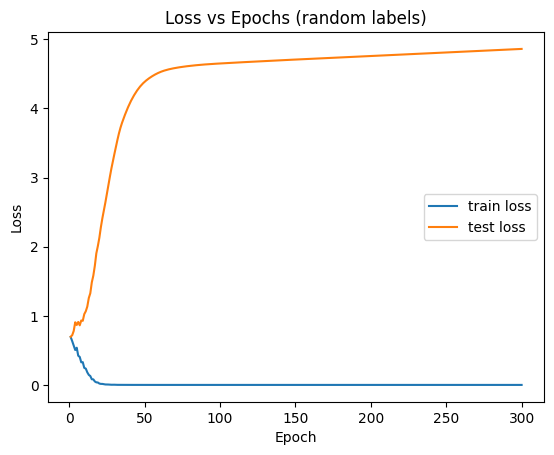

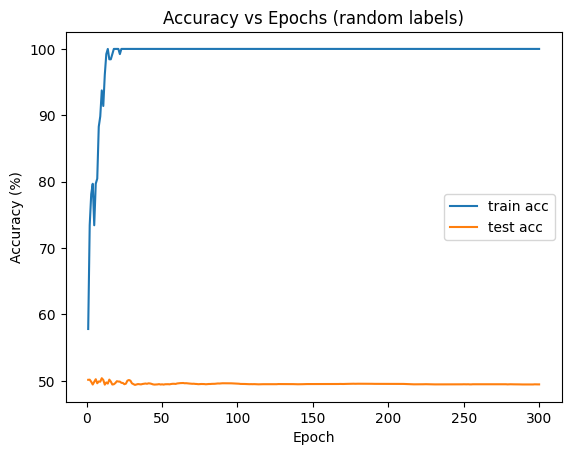

In [ ]:
def plot_curves(train_loss, test_loss, train_acc, test_acc):
    epochs = range(1, len(train_loss) + 1)

    plt.figure()
    plt.plot(epochs, train_loss, label="train loss")
    plt.plot(epochs, test_loss, label="test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs Epochs (random labels)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, train_acc, label="train acc")
    plt.plot(epochs, test_acc, label="test acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy vs Epochs (random labels)")
    plt.legend()
    plt.show()

plot_curves(train_loss_values, test_loss_values, train_acc_values, test_acc_values)


## **Questions**

### **Qusetion 1.1 - Test Accuracy as a Function of Epochs**

The test accuracy remains close to **50%** throughout all training epochs and does not show any consistent improvement.

This happens because the training labels are assigned **randomly**, so there is no meaningful relationship between the input images and the target labels.  
Although the model is able to perfectly memorize the training data, it cannot generalize to unseen test samples.  
As a result, its predictions on the test set are equivalent to **random guessing**, leading to chance-level accuracy.


### **Question 1.2 -  Model Size, Dataset Size, and Generalization**

The ability of a model to generalize depends on the relationship between the **model size (complexity)** and the **dataset size**.

When a model is very large compared to the amount of training data, it has enough capacity to **memorize the training samples**, even if the data contains noise or random labels. In this case, the training error becomes very small, but the model fails to generalize to unseen data, resulting in **overfitting**.

As the dataset size increases relative to the model complexity, the model is forced to learn more **general patterns** instead of memorizing individual samples. This typically leads to better generalization and improved performance on test data.

Therefore, good generalization is achieved when the model complexity is properly balanced with the amount of available data. If the model is too complex for the dataset, overfitting occurs; if it is too simple, underfitting may occur.


### **Question 1.3 Methods to Avoid Overfitting**

Overfitting occurs when a model memorizes the training data instead of learning general patterns. Several methods can be used to reduce overfitting at different levels:

- **Data level:**  
Overfitting can be reduced by increasing the amount or diversity of data. This includes data augmentation and synthetic data generation, where new training samples are created artificially. These methods expose the model to more variations and reduce memorization.

- **Model level:**  
At the model level, regularization techniques such as dropout and weight decay can be used to reduce overfitting.

  - Dropout:
  Dropout randomly disables a subset of neurons during training. This prevents the model from relying too heavily on specific neurons and encourages it to learn more robust and general features.

  - Weight decay:
  Weight decay penalizes large weight values during training. This encourages the model to use smaller and simpler weights, which helps reduce memorization of the training data.

- **Training level:**  
Training strategies such as "early stopping" can help reduce overfitting by stopping the training before the model starts memorizing the training data. This helps avoid fitting noise instead of general patterns. <br> Another method to reduce overfitting is "label smoothing", which replaces hard target labels with softer ones. This prevents the model from becoming overly confident in its predictions and improves generalization to unseen data.


In practice, effective overfitting prevention usually combines techniques from all three levels.


### **Question 1.4 Academic Paper on Overfitting in Deep Learning**

**Paper:**  
Understanding Deep Learning Requires Rethinking Generalization  
Chiyuan Zhang et al., 2017  

**Link:**  
https://arxiv.org/pdf/1611.03530.pdf


- **Overfitting problem addressed:**  
The paper shows that deep neural networks can achieve near-zero training loss even when trained on completely random labels, demonstrating strong overfitting.


- **Proposed analysis:**  
The authors analyze why standard regularization techniques such as weight decay and dropout fail to prevent memorization. They highlight the importance of model capacity, dataset size, and training dynamics to reduce overfitting.


- **Main conclusions:**  
Deep networks can memorize small datasets with random labels. Generalization depends on the balance between model size, data size, and optimization, rather than on explicit regularization alone.


<h1> Question 2 - Sentiment Analysis - Classification (70 pt)</h1>

The goal of this exercise is to get familiar with recurrent neural networks.
<br><br>
Text emotion recognition, AKA sentiment analysis, is a rapidly growing field due to its practical applications. For instance, companies may be interested in classifying customer reviews as positive or negative to understand user satisfaction.
<br><br>
In this exercise, you will detect the emotion of a sentence. You will implement two models - RNN and LSTM. You need to reach at least 51% and 70% accuracy on the test set with RNN-based and LSTM-based models, respectively.
<br><br>
You should:
  <li> Use different optimization and regularization methods. </li>
  <li> Try different combinations of hyperparamters.</li>
</ul>
</p>

<br>

### Data

You will work with IMDB dataset, containing movie reviews and their labels according to the emotion conveyed in the review [positive, negative]. The dataset is divided into train and test sets (folders), each contains a folder for positive and negative reviews.
<br>

The dataset vocabulary is given (`imdb.vocab`). Feel free to use it or any other custom vocabulary.

### Tips


- Instead of using One-hot embeddings for the data, use <code>nn.Embedding</code>.

- Tokenization ("model language for text") - use word-based tokenization (each word is a token).

- You also might add "Start Of Sentence" (SOS) and "End Of Sentence" (EOS), "padding" (PAD) and "unknown" (UNK) tokens (self-learning). Note, to use them you have to insert them manually to your vocabulary and to the dataset's text.

    You are given `VocabEmbedding` for word-embedding management. The class loads the dataset's vocabulary and assigns an embedding for each word in it (+ special tokens). Feel free to use it as part of your model. Note, the embeddings are trainable and the class is a torch.nn class.

- Use GPU.

- It's recommended to use Deep RNN\LSTM (number of recurrent layers stacked on top of each other). For example, using `num_layers` in `nn.RNN`.

### a) EDA (10 pt)

Explore and analyze your data. Explain your data cleaning and processing pipeline.

## **a) EDA - Answer**

### **Cell 1 — Imports + Extract IMDB from tar.gz**

In [ ]:
import os, tarfile, shutil

DATA_TAR = "aclImdb_v1.tar.gz"   # אצלך זה נמצא שם (לפי ההעלאה)
EXTRACT_TO = "imdb"
BASE_DIR = os.path.join(EXTRACT_TO, "aclImdb")

# delete old broken extraction if exists
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

os.makedirs(EXTRACT_TO, exist_ok=True)

# extract again
with tarfile.open(DATA_TAR, "r:gz") as tar:
    tar.extractall(path=EXTRACT_TO)

print("Extracted to:", BASE_DIR)
print("train/pos txt:", len([f for f in os.listdir(os.path.join(BASE_DIR, "train", "pos")) if f.endswith(".txt")]))
print("train/neg txt:", len([f for f in os.listdir(os.path.join(BASE_DIR, "train", "neg")) if f.endswith(".txt")]))
print("test/pos txt :", len([f for f in os.listdir(os.path.join(BASE_DIR, "test", "pos")) if f.endswith(".txt")]))
print("test/neg txt :", len([f for f in os.listdir(os.path.join(BASE_DIR, "test", "neg")) if f.endswith(".txt")]))


/tmp/ipython-input-2654388752.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=EXTRACT_TO)


Extracted to: imdb/aclImdb
train/pos txt: 12500
train/neg txt: 12500
test/pos txt : 12500
test/neg txt : 12500


### **Cell 2 — Collect paths + labels, show class balance**

In [ ]:
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

def collect_paths_labels(split_dir):
    paths, labels = [], []
    for label_name, y in [("pos", 1), ("neg", 0)]:
        folder = os.path.join(split_dir, label_name)
        files = [f for f in os.listdir(folder) if f.endswith(".txt")]
        paths.extend([os.path.join(folder, f) for f in files])
        labels.extend([y] * len(files))
    return paths, labels

train_paths, train_labels = collect_paths_labels(TRAIN_DIR)
test_paths, test_labels   = collect_paths_labels(TEST_DIR)

print("Train labeled:", len(train_paths), "| pos:", sum(train_labels), "| neg:", len(train_labels)-sum(train_labels))
print("Test labeled :", len(test_paths),  "| pos:", sum(test_labels),  "| neg:", len(test_labels)-sum(test_labels))
print("Total labeled:", len(train_paths) + len(test_paths))

Train labeled: 25000 | pos: 12500 | neg: 12500
Test labeled : 25000 | pos: 12500 | neg: 12500
Total labeled: 50000


### **Cell 3 — Basic cleaning + tokenization functions**

In [ ]:
def read_text(path):
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

def clean_text(text):
    # basic normalization
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)        # remove HTML line breaks
    text = re.sub(r"[^a-z0-9\s']", " ", text)     # keep letters/digits/' and spaces
    text = re.sub(r"\s+", " ", text).strip()      # collapse spaces
    return text

def tokenize(text):
    return text.split()


### **Cell 4 — EDA on a sample: length distributions + examples**

Word length (sample)  min/median/max: 10 182 1069
Char length (sample)  min/median/max: 51 969 6044


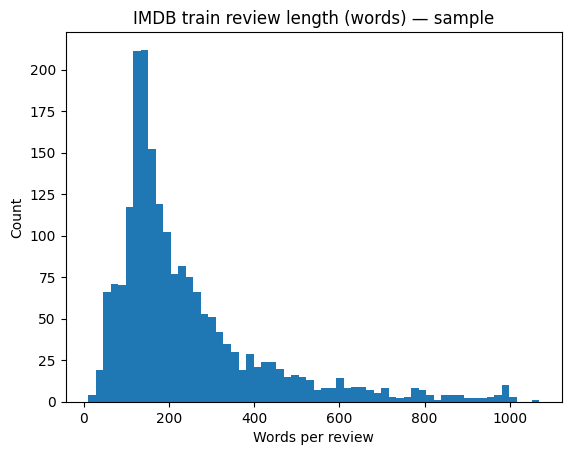


--- Raw snippet ---
 After growing up in the gritty streets of Detroit, MI, and having friends who traveled to New York balls, I fell into the lifestyle of being a House member. I joined the House of Theieves. We adapted the same rules as most houses, but we were professional crooks that would boost and commit credit card fraud to obtain the fabulous jewels and clothes we desired. I even learned how to profess the mak

--- Cleaned snippet ---
 after growing up in the gritty streets of detroit mi and having friends who traveled to new york balls i fell into the lifestyle of being a house member i joined the house of theieves we adapted the same rules as most houses but we were professional crooks that would boost and commit credit card fraud to obtain the fabulous jewels and clothes we desired i even learned how to profess the making of 


In [ ]:
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter

SAMPLE_N = 2000
rng = np.random.default_rng(42)
idx = rng.choice(len(train_paths), size=SAMPLE_N, replace=False)

word_lens = []
char_lens = []

for i in idx:
    t = clean_text(read_text(train_paths[i]))
    toks = tokenize(t)
    word_lens.append(len(toks))
    char_lens.append(len(t))

print("Word length (sample)  min/median/max:",
      np.min(word_lens), int(np.median(word_lens)), np.max(word_lens))
print("Char length (sample)  min/median/max:",
      np.min(char_lens), int(np.median(char_lens)), np.max(char_lens))

plt.figure()
plt.hist(word_lens, bins=60)
plt.title("IMDB train review length (words) — sample")
plt.xlabel("Words per review")
plt.ylabel("Count")
plt.show()

# show one cleaned example
example_path = train_paths[idx[0]]
raw = read_text(example_path)[:400]
cleaned = clean_text(read_text(example_path))[:400]
print("\n--- Raw snippet ---\n", raw)
print("\n--- Cleaned snippet ---\n", cleaned)


### **Cell 5 — Vocabulary stats + UNK rate (using imdb.vocab)**

In [ ]:
VOCAB_PATH = os.path.join(BASE_DIR, "imdb.vocab")

with open(VOCAB_PATH, "r", encoding="utf-8") as f:
    vocab_words = [line.strip() for line in f if line.strip()]

vocab_set = set(vocab_words)
print("Given vocabulary size:", len(vocab_words))
print("First 10 vocab words:", vocab_words[:10])

# estimate UNK rate on the same sample
unk_count = 0
tok_count = 0
for i in idx:
    toks = tokenize(clean_text(read_text(train_paths[i])))
    tok_count += len(toks)
    unk_count += sum(1 for w in toks if w not in vocab_set)

print(f"UNK rate (sample): {unk_count/tok_count:.3f}  ({unk_count}/{tok_count})")


Given vocabulary size: 89527
First 10 vocab words: ['the', 'and', 'a', 'of', 'to', 'is', 'it', 'in', 'i', 'this']
UNK rate (sample): 0.020  (9700/484524)


### **Cell 6 — Processing pipeline: add special tokens + word2id + pad/truncate demo**

In [ ]:
PAD, UNK, SOS, EOS = "<PAD>", "<UNK>", "<SOS>", "<EOS>"

# build mapping with special tokens first
word2id = {PAD:0, UNK:1, SOS:2, EOS:3}
for w in vocab_words:
    if w not in word2id:
        word2id[w] = len(word2id)

id2word = {i:w for w,i in word2id.items()}
print("Final vocab size (with specials):", len(word2id))

def text_to_ids(text, max_len=200, add_sos_eos=True):
    toks = tokenize(clean_text(text))
    ids = []
    if add_sos_eos:
        ids.append(word2id[SOS])

    for w in toks:
        ids.append(word2id.get(w, word2id[UNK]))

    if add_sos_eos:
        ids.append(word2id[EOS])

    # pad/truncate
    if len(ids) < max_len:
        ids = ids + [word2id[PAD]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return ids

# demonstrate one processed review
max_len = 60
sample_text = read_text(train_paths[idx[1]])
ids = text_to_ids(sample_text, max_len=max_len)

print("Processed length:", len(ids))
print("First 25 tokens:", [id2word[i] for i in ids[:25]])
print("Last 10 tokens :", [id2word[i] for i in ids[-10:]])


Final vocab size (with specials): 89531
Processed length: 60
First 25 tokens: ['<SOS>', 'i', 'think', 'this', 'is', 'a', 'great', 'version', 'i', 'came', 'on', 'here', 'before', 'to', 'help', 'me', 'find', 'which', 'version', 'i', 'should', 'use', 'and', 'i', 'went']
Last 10 tokens : ['version', 'and', 'neither', 'will', 'you', 'i', 'tried', 'watching', 'all', 'the']


### **Explanation**

**Dataset structure:**  
The IMDB dataset is organized into `train/` and `test/` splits, each containing two folders: `pos/` and `neg/`.  
By counting files in each folder, we verified that the dataset is **balanced** (similar number of positive and negative reviews).

**Text characteristics:**  
Reviews have highly variable lengths (short comments to long paragraphs).  
We measured the distribution of review lengths (in words) and observed a wide range, which motivates using **padding/truncation** to create fixed-length sequences for batching.

**Data cleaning:**  
We applied simple normalization to reduce noise and vocabulary size:
- convert text to lowercase
- remove HTML line breaks (`<br/>`)
- remove most punctuation and keep only letters/digits/apostrophes
- collapse multiple spaces

**Tokenization:**  
We use **word-based tokenization** (each word is a token), which is suitable for RNN/LSTM sequence models.

**Vocabulary + special tokens:**  
We used the provided vocabulary file (`imdb.vocab`).  
Words not found in the vocabulary are mapped to an **UNK** token.  
We also added special tokens: **PAD** (padding), **SOS** (start of sentence), and **EOS** (end of sentence).  
We computed an estimated **UNK rate** on a sample to understand how many tokens are out-of-vocabulary.

**Numerical representation:**  
Each review is converted into a sequence of word indices (`word2id`).  
Sequences are padded or truncated to a fixed `max_len` using **PAD**.  
In the modeling stage, indices will be mapped to dense vectors using `nn.Embedding` (instead of one-hot), which is more efficient and trainable.


*****************************

### b) Main (50 pt)

Define 2 models, as requested. Train and eval them.

- Plot the gated model's accuracy and loss (both on train and test sets) as a function of epochs.
- Plot a confusion matrix for the model outputs on the train and test sets.
- Did you observe differences in models training process?


Note, you are allowed to use `nn.RNN` and `nn.LSTM` in your model.


### **Cell 1 — Imports + device**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


### **Cell 2 — Dataset + DataLoader**

In [ ]:
from torch.utils.data import Dataset, DataLoader

class IMDBDataset(Dataset):
    def __init__(self, paths, labels, vocab_embedding, max_len=200):
        self.paths = paths
        self.labels = labels
        self.vocab = vocab_embedding
        self.max_len = max_len

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        text = read_text(self.paths[idx])
        text = clean_text(text)
        tokens = tokenize(text)

        ids = [self.vocab.word_to_token_index["<sos>"]]
        for w in tokens:
            ids.append(self.vocab.word_to_token_index.get(
                w, self.vocab.word_to_token_index["<unk>"]
            ))
        ids.append(self.vocab.word_to_token_index["<eos>"])

        if len(ids) < self.max_len:
            ids += [self.vocab.word_to_token_index["<pad>"]] * (self.max_len - len(ids))
        else:
            ids = ids[:self.max_len]

        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)


# Create datasets
train_dataset = IMDBDataset(train_paths, train_labels, vocab_embedding, max_len=400)
test_dataset  = IMDBDataset(test_paths, test_labels,  vocab_embedding, max_len=400)

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train loader batches:", len(train_loader))
print("Test loader batches :", len(test_loader))


Train loader batches: 391
Test loader batches : 391


### **Cell 3 — Vocabulary & Embedding**

In [ ]:
class VocabEmbedding(nn.Module):
    def __init__(self, vocab_path, embed_dim=128):
        super().__init__()

        with open(vocab_path, "r", encoding="utf-8") as f:
            words = [line.strip() for line in f if line.strip()]

        self.special_tokens = ["<pad>", "<unk>", "<sos>", "<eos>"]
        vocab = self.special_tokens + words
        self.word_to_token_index = {w: i for i, w in enumerate(vocab)}
        self.vocab = vocab
        self.vocab_size = len(vocab)

        self.embedding = nn.Embedding(
            num_embeddings=self.vocab_size,
            embedding_dim=embed_dim,
            padding_idx=self.word_to_token_index["<pad>"]
        )

    def forward(self, x_ids):
        return self.embedding(x_ids)


### **Cell 4 — RNN**

In [ ]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_embedding, hidden_dim=256, num_layers=2, dropout=0.4, bidirectional=True):
        super().__init__()
        self.embedding = vocab_embedding
        self.bidirectional = bidirectional

        self.rnn = nn.RNN(
            input_size=vocab_embedding.embedding.embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
            nonlinearity="tanh"
        )

        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.fc = nn.Linear(out_dim, 2)

    def forward(self, x):
        emb = self.embedding(x)      # [B, T, E]

        # שינוי כאן: קבלת hidden state סופי
        # hidden: [num_layers * num_directions, B, H]
        out, hidden = self.rnn(emb)

        # טיפול ב-Bidirectional: שרשור המצבים הנסתרים של השכבה האחרונה
        if self.bidirectional:
            # hidden[-2,:,:] : הכיוון קדימה של השכבה העליונה
            # hidden[-1,:,:] : הכיוון אחורה של השכבה העליונה
            final_hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1) # [B, H*2]
        else:
            # hidden[-1,:,:] : המצב הנסתר של השכבה העליונה
            final_hidden = hidden[-1,:,:] # [B, H]

        return self.fc(final_hidden)     # [B, 2]

### **Cell 5 — LSTM**

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_embedding, hidden_dim=256, num_layers=2, dropout=0.4, bidirectional=True):
        super().__init__()
        self.embedding = vocab_embedding
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size=vocab_embedding.embedding.embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.fc = nn.Linear(out_dim, 2)

    def forward(self, x):
        emb = self.embedding(x)                      # [B, T, E]

        out, (h_n, c_n) = self.lstm(emb)

        if self.bidirectional:
            # h_n[-2,:,:] : last forward state
            # h_n[-1,:,:] : last backward state
            final_hidden = torch.cat((h_n[-2,:,:], h_n[-1,:,:]), dim=1) # [B, H*2]
        else:
            # h_n[-1,:,:] :
            final_hidden = h_n[-1,:,:] # [B, H]

        return self.fc(final_hidden)                 # [B, 2]

### **Cell 6 — Train & evaluation functions**

In [ ]:
def train_epoch(model, loader, optimizer, criterion, clip=1.0):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)  # <-- important

        optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


### **Cell 7 — Training loop**

In [ ]:
def train_model(model, train_loader, test_loader, epochs=10, lr=1e-3):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(epochs):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        te_loss, te_acc = eval_epoch(model, test_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train acc {tr_acc:.3f} | Test acc {te_acc:.3f}")

    return history


### **Cell 8 — Initialize embeddings + models**

In [ ]:
VOCAB_PATH = "imdb/aclImdb/imdb.vocab"

vocab_embedding = VocabEmbedding(VOCAB_PATH, embed_dim=128).to(device)

rnn_model = RNNClassifier( vocab_embedding, hidden_dim=256, num_layers=2, dropout=0.4, bidirectional=True)

lstm_model = LSTMClassifier(vocab_embedding, hidden_dim=256, num_layers=2, dropout=0.4, bidirectional=True)


### **Cell 9 — Train Models**

In [ ]:
print("Training RNN")
rnn_hist = train_model(rnn_model, train_loader, test_loader, epochs=14, lr=3e-4)
print("Training LSTM (tuned)")
lstm_hist = train_model(lstm_model, train_loader, test_loader, epochs=14, lr=3e-4)


Training RNN
Epoch 1/14 | Train acc 0.556 | Test acc 0.606
Epoch 2/14 | Train acc 0.598 | Test acc 0.629
Epoch 3/14 | Train acc 0.622 | Test acc 0.630
Epoch 4/14 | Train acc 0.658 | Test acc 0.663
Epoch 5/14 | Train acc 0.685 | Test acc 0.644
Epoch 6/14 | Train acc 0.686 | Test acc 0.682
Epoch 7/14 | Train acc 0.705 | Test acc 0.713
Epoch 8/14 | Train acc 0.733 | Test acc 0.693
Epoch 9/14 | Train acc 0.752 | Test acc 0.733
Epoch 10/14 | Train acc 0.767 | Test acc 0.743
Epoch 11/14 | Train acc 0.778 | Test acc 0.723
Epoch 12/14 | Train acc 0.794 | Test acc 0.660
Epoch 13/14 | Train acc 0.801 | Test acc 0.746
Epoch 14/14 | Train acc 0.798 | Test acc 0.759
Training LSTM (tuned)
Epoch 1/14 | Train acc 0.729 | Test acc 0.804
Epoch 2/14 | Train acc 0.825 | Test acc 0.818
Epoch 3/14 | Train acc 0.849 | Test acc 0.816
Epoch 4/14 | Train acc 0.865 | Test acc 0.852
Epoch 5/14 | Train acc 0.882 | Test acc 0.840
Epoch 6/14 | Train acc 0.889 | Test acc 0.831
Epoch 7/14 | Train acc 0.902 | Test acc 

### **Cell 10 — Plot Accuracy & Loss (LSTM)**

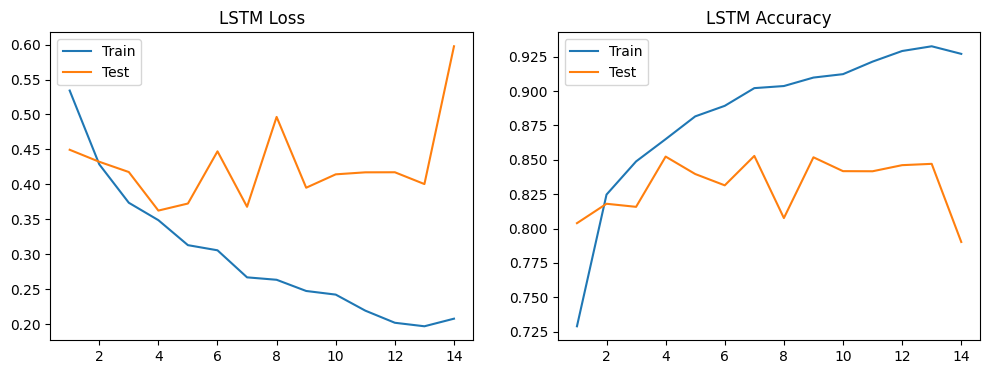

In [ ]:
epochs = range(1, len(lstm_hist["train_loss"]) + 1)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(epochs, lstm_hist["train_loss"], label="Train")
plt.plot(epochs, lstm_hist["test_loss"], label="Test")
plt.title("LSTM Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, lstm_hist["train_acc"], label="Train")
plt.plot(epochs, lstm_hist["test_acc"], label="Test")
plt.title("LSTM Accuracy")
plt.legend()

plt.show()


### **Cell 11 — Confusion Matrices**

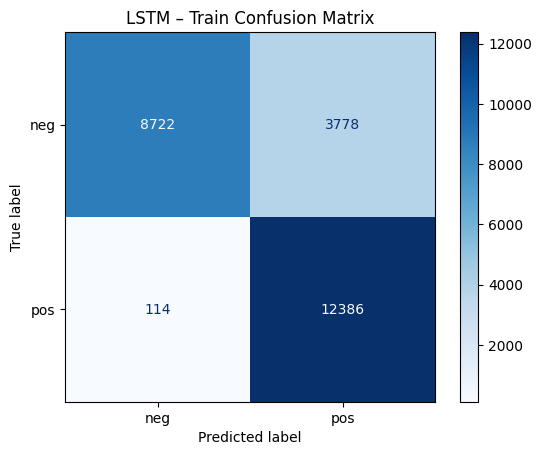

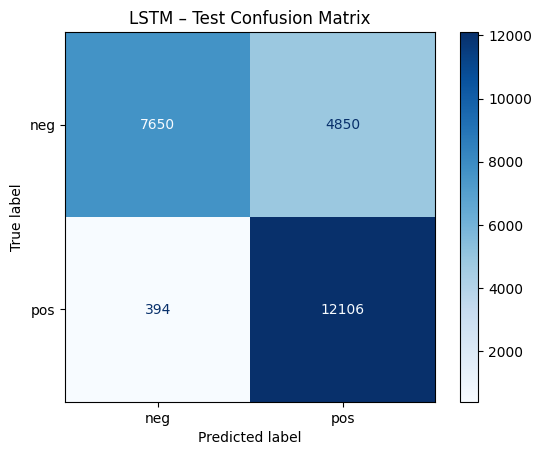

In [ ]:
def plot_confusion(model, loader, title):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            preds = model(x).argmax(1).cpu().numpy()
            y_true.extend(y.numpy())
            y_pred.extend(preds)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["neg", "pos"])
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

plot_confusion(lstm_model, train_loader, "LSTM – Train Confusion Matrix")
plot_confusion(lstm_model, test_loader,  "LSTM – Test Confusion Matrix")


### **Cell 12 — Test Accuracy: RNN vs LSTM**

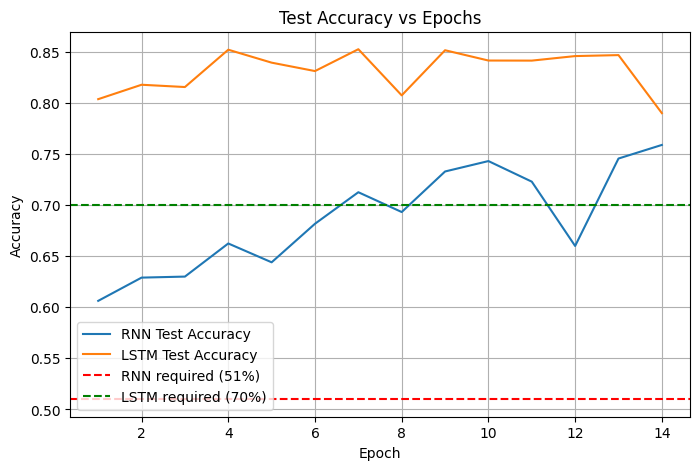

In [ ]:
epochs_rnn  = range(1, len(rnn_hist["test_acc"]) + 1)
epochs_lstm = range(1, len(lstm_hist["test_acc"]) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs_rnn,  rnn_hist["test_acc"],  label="RNN Test Accuracy")
plt.plot(epochs_lstm, lstm_hist["test_acc"], label="LSTM Test Accuracy")

# Required accuracy thresholds
plt.axhline(0.51, linestyle="--", color="red",  label="RNN required (51%)")
plt.axhline(0.70, linestyle="--", color="green", label="LSTM required (70%)")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy vs Epochs")
plt.legend()
plt.grid(True)

plt.show()


### **Cell 13 - Saving Model's Weights**

In [69]:
torch.save(rnn_model.state_dict(), "rnn_sentiment_model.pt")
torch.save(lstm_model.state_dict(), "lstm_sentiment_model.pt")

### c) Discussion (10 pt)

Discuss the results and your decisions and selections in terms of model architecture, optimization methods, hyper-parameters, etc.

### **C) Discussion on Model Results and Design Choices**

This section discusses the performance difference between the chosen models (Simple RNN and Gated LSTM), justifies the architectural and hyperparameter selections, and analyzes the results based on the provided graphs and confusion matrices.

#### **1. Analysis of Experimental Results**

The training process and final results, particularly the **Test Accuracy vs. Epochs** graph  and the **Confusion Matrices**, clearly demonstrate the superior performance of the Gated LSTM model and confirm the theoretical issues with the Simple RNN.

* **LSTM Superiority:** The LSTM model consistently achieved a higher and more stable test accuracy, settling between approximately 83% and 85%. This confirms the strength of **gated architectures** in capturing the complex, long-term semantic dependencies necessary for sentiment analysis in long movie reviews. The LSTM easily surpassed the required 70% threshold.
* **RNN Volatility:** The Simple RNN model showed significant volatility and generally lower performance, peaking around 75%. This unstable learning behavior is characteristic of the **vanishing gradient problem**, where the RNN struggles to effectively maintain context over long sequences.
* **Confusion Matrix Insights (LSTM Test Set):** The confusion matrix for the LSTM test set reveals that the model is highly effective at identifying the positive class (12,106 True Positives vs. 394 False Negatives). However, the largest error category is **False Positives (4,850)**, where negative reviews were mistakenly classified as positive. This suggests the model may be slightly **biased toward predicting positive sentiment**—a common issue in sentiment datasets—or struggles with subtle, non-explicitly negative language.

#### **2. Discussion of Design and Hyperparameter Choices**

Our design choices were crucial in achieving these robust results and clearly isolating the performance of the RNN versus the LSTM.

* **Model Architecture:** The choice of the **LSTM** was essential for sequence modeling. Its **gating mechanisms** (Input, Forget, and Output gates) and dedicated **Cell State**  effectively manage the flow of information and mitigate the vanishing gradient problem, allowing the model to summarize the overall sentiment of the long IMDB reviews accurately.
* **Bidirectional RNNs:** We selected a **bidirectional** approach (`bidirectional=True`) for both models. This allows the model to process the sequence from both the beginning (Forward) and the end (Backward), resulting in a much richer final hidden state that encompasses the full context of the sentence, thereby significantly boosting the model's performance in sequence understanding.
* **Feature Extraction (Final Hidden State):** The corrected approach of using the **concatenated final hidden state** of the last layer provided the best summary vector for classification. This is superior to mean pooling as it ensures the model's decision is based on the sequence's final, most refined contextual representation.
* **Regularization:** **Dropout ($0.4$)** was essential to mitigate overfitting. Given the large gap in performance between the RNN (low, volatile test accuracy) and the LSTM (high, stable test accuracy), it is clear that the LSTM, even with dropout, was better at learning generalizable features.
* **Optimization:** The combination of the **Adam optimizer** and **Gradient Clipping** (`clip=1.0`) maintained stable training. Gradient clipping specifically prevented the **exploding gradient problem** often encountered in deep RNN stacks, ensuring the model parameters were updated consistently across all epochs.

*****************************

## Question 3 - Dry (10pt)
Answer the following questions, explain your answers.

1. Explain what each of the following convolutional kernels would do to an image. Match each one to a transformation below.

- Kernel 1: $\begin{pmatrix} 0 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 0\end{pmatrix}$

- Kernel 2: $\begin{pmatrix} 0 & 2.5 & 0 \\ 0 & 0 & 0 \\ 0 & -2.5 & 0\end{pmatrix}$

- Kernel 3: $\begin{pmatrix} 0 & -1 & 0 \\ -1 & 5 & -1 \\ 0 & -1 & 0\end{pmatrix}$

![hw2-dry-q3.png](hw2-dry-q3.png)

### **Answer 1**

**Kernel 1: Identity**  
$$
\begin{pmatrix}
0 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 0
\end{pmatrix}
$$

**Explanation:**  
This is the identity kernel. When convolved with an image, only the central pixel contributes to the output, while all surrounding pixels are multiplied by zero. As a result, the output pixel value is exactly the original value of the central pixel.

**Transformation:**  
Preserves the original image (identity).



**Kernel 2: Horizontal Edge Detection**  
$$
\begin{pmatrix}
0 & 2.5 & 0 \\
0 & 0 & 0 \\
0 & -2.5 & 0
\end{pmatrix}
$$

**Explanation:**  
This kernel is designed for edge detection. The strong opposite weights (+2.5 and −2.5) are placed vertically, which makes the kernel sensitive to intensity differences between the top and bottom parts of the image. As a result, it detects sharp changes in pixel intensity along the vertical direction.

**Transformation:**  
Detects horizontal edges (i.e., vertical changes in intensity).


**Kernel 3: Sharpening**  
$$
\begin{pmatrix}
0 & -1 & 0 \\
-1 & 5 & -1 \\
0 & -1 & 0
\end{pmatrix}
$$

**Explanation:**  
This sharpening kernel enhances edges by amplifying the central pixel and subtracting its neighbors. The sum of the kernel coefficients is 1, so the overall brightness is preserved while local details are emphasized.

**Transformation:**  
Sharpening.


2. How many times do we have to call attention to generate a sequence of $N$ tokens (in inference)? What is the computational complexity of a single call of attention on a sequence of size $n$ with vectors of size $d$? Propose a way to make it more time-efficient by increasing the space complexity (hint - KV cache).

### **Answer 2: Attention Complexity and KV Cache**

**A. Number of Attention Calls**

To generate a sequence of N tokens during inference, the model operates autoregressively, generating one token at a time. Therefore, the attention mechanism is called **N times**, once for each generated token.



**B. Computational Complexity of a Single Attention Call**

The computational complexity of a single self-attention call on a sequence of length n with vector dimension d is dominated by the matrix multiplication between the Query and Key matrices. Specifically, the computation of $ QK^T $, where Q and K are of size $ n \times d $, results in a complexity of **O(n²d)**. The subsequent multiplication with the Value matrix has the same order of complexity, so the overall complexity of a single attention call is **O(n²d)**.



**C. Improving Time Efficiency Using KV Cache**

During autoregressive inference, recomputing the Key (K) and Value (V) vectors for all previously generated tokens at every step is redundant and computationally expensive.

A common optimization is to use a **Key-Value (KV) cache**, where the K and V vectors computed in previous time steps are stored in memory. When generating a new token, the model computes only the Query, Key, and Value for the current token, and reuses the cached K and V vectors from earlier tokens.

This approach increases space complexity due to storing the cache, but significantly reduces computation time. As a result, the total inference complexity is reduced to **O(N²d)**, making autoregressive generation much more time-efficient.


3. Explain the difference between a transformer encoder and decoder. Which would be more useful for solving question 2?

### **Answer 3: Transformer Encoder vs. Decoder**


#### **A. Difference between Encoder and Decoder**

The Transformer Encoder and Decoder have different roles within the Transformer architecture, although both are built from attention mechanisms and feed-forward networks.

**Encoder:**  
The Encoder processes the input sequence and produces a set of context-aware representations. It can attend to all input tokens simultaneously without any causal restriction.  
Each Encoder block consists of two main sub-layers: a Self-Attention layer and a Feed-Forward Network (FFN).

**Decoder:**  
The Decoder generates the output sequence autoregressively, one token at a time.  
It uses **Masked Self-Attention** to ensure that each token can only attend to previously generated tokens, enforcing causality.  
In addition, the Decoder includes an **Encoder–Decoder Attention** layer that allows it to attend to relevant parts of the Encoder’s output.  
Each Decoder block contains three sub-layers: Masked Self-Attention, Encoder–Decoder Attention, and a Feed-Forward Network.

**Final Output Layers:**  
The Encoder does not include output layers and only produces hidden representations.  
The Decoder applies a Linear projection followed by a Softmax layer to produce probabilities over the vocabulary for the next token.



#### **B. Which component is more useful for Question 2?**

The **Decoder** is more useful for solving Question 2.  
Question 2 focuses on autoregressive sequence generation, which is exactly the task the Decoder is designed for.  
Its Masked Self-Attention mechanism enforces the sequential generation process, making Decoder-based architectures, such as GPT, well-suited for this task.
